# Chain to TMatrixC

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import treams

In [3]:
k0 = 2 * np.pi / 700
materials = [treams.Material(-16.5 + 1j), treams.Material()]
lmax = mmax = 3
radii = [75, 65]
positions = [[-30, 0, -75], [30, 0, 75]]
lattice = treams.Lattice(300)
kz = 0.005

In [4]:
spheres = [treams.TMatrix.sphere(lmax, k0, r, materials) for r in radii]
chain = treams.TMatrix.cluster(spheres, positions).latticeinteraction.solve(lattice, kz)

In [5]:
bmax = 3.1 * lattice.reciprocal
cwb = treams.CylindricalWaveBasis.diffr_orders(kz, mmax, lattice, bmax, 2, positions)
chain_tmc = treams.TMatrixC.from_array(chain, cwb)

/home/runner/work/treams/treams/src/treams/_operators.py:532: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  res = cw.to_sw(
/home/runner/work/treams/treams/src/treams/_operators.py:829: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  res = sw.periodic_to_cw(


In [6]:
inc = treams.plane_wave(
    [np.sqrt(k0 ** 2 - kz ** 2), 0, kz],
    [np.sqrt(0.5), np.sqrt(0.5)],
    k0=chain.k0,
    material=chain.material,
)
sca = chain_tmc @ inc.expand(chain_tmc.basis)

/home/runner/work/treams/treams/src/treams/_operators.py:607: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  res = pw.to_cw(


In [7]:
x = np.linspace(-300, 300, 61)
y = 0
z = np.linspace(-150, 150, 31)
xx, zz = np.meshgrid(x, z, indexing="ij")
yy = np.full_like(xx, y)
grid = np.stack((xx, yy, zz), axis=-1)

In [8]:
ez = np.zeros_like(xx, complex)
valid = chain_tmc.valid_points(grid, radii)
ez[valid] = (inc.efield(grid[valid]) + sca.efield(grid[valid]))[..., 2]
ez[~valid] = np.nan
sca = chain @ inc.expand(chain.basis)
valid = ~valid & chain.valid_points(grid, radii)
vals = []
for i, r in enumerate(grid[valid]):
    swb = treams.SphericalWaveBasis.default(1, positions=[r])
    field = sca.expandlattice(basis=swb).efield(r)
    vals.append(inc.efield(r)[2] + field[2])
ez[valid] = vals

/home/runner/work/treams/treams/src/treams/_operators.py:555: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  res = pw.to_sw(


In [9]:
ez = np.concatenate(
    (
        np.real(ez * np.exp(-1j * kz * lattice[...])),
        ez.real,
        np.real(ez * np.exp(1j * kz * lattice[...])),
    ),
    axis=1,
)
xx = np.tile(xx, (1, 3))
zz = np.concatenate((zz - lattice[...], zz, zz + lattice[...]), axis=1)

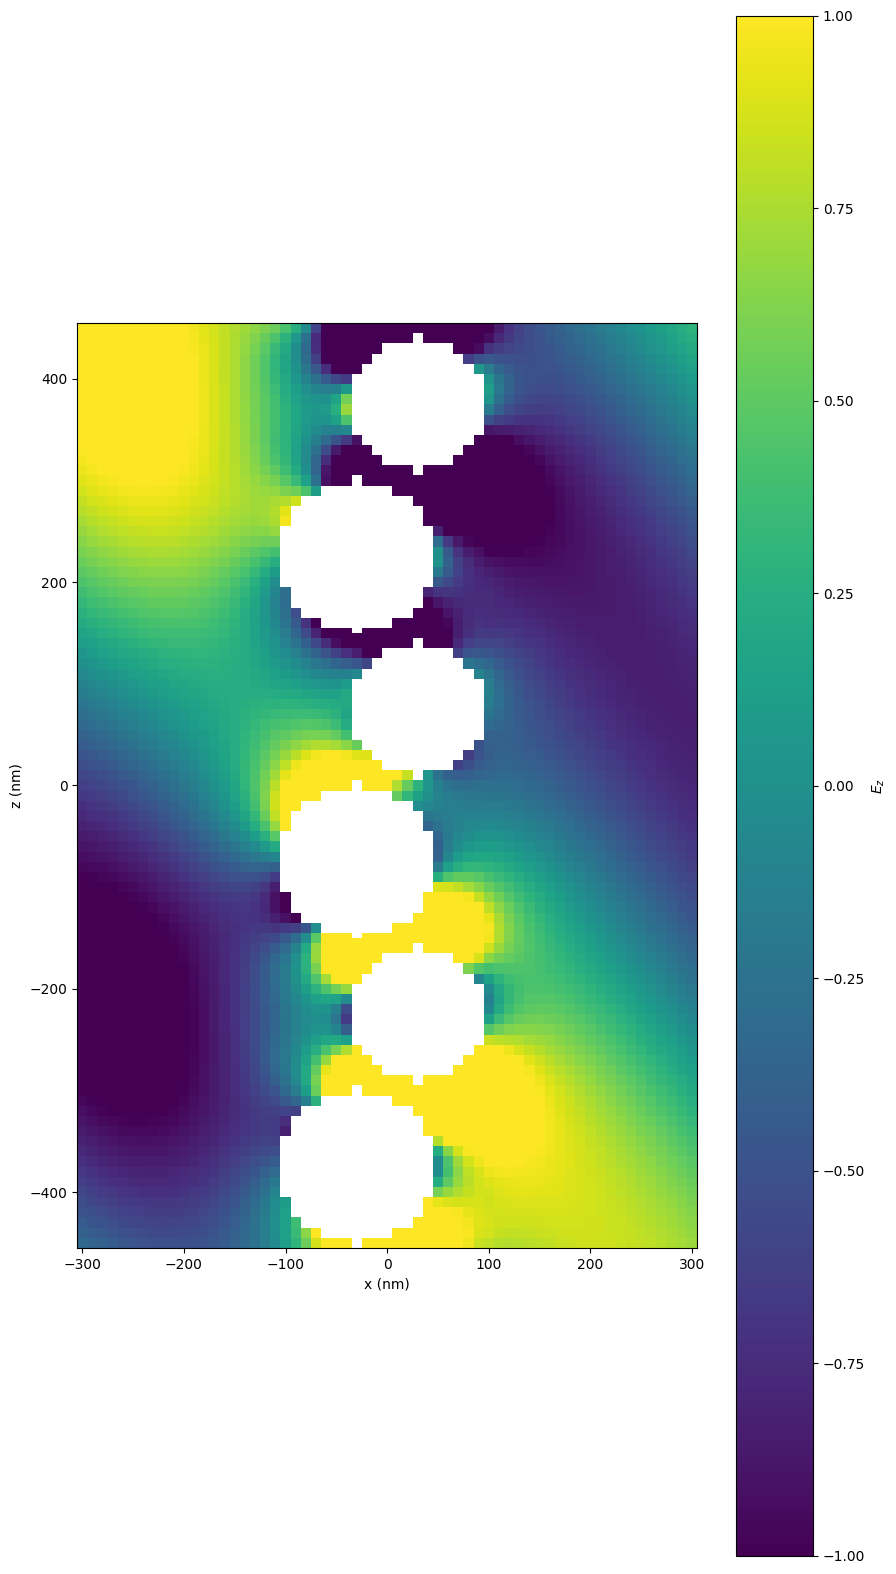

In [10]:
fig, ax = plt.subplots(figsize=(10, 20))
pcm = ax.pcolormesh(xx, zz, ez, shading="nearest", vmin=-1, vmax=1,)
cb = plt.colorbar(pcm)
cb.set_label("$E_z$")
ax.set_xlabel("x (nm)")
ax.set_ylabel("z (nm)")
ax.set_aspect("equal")
fig.show()